In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_excel("../data/raw/credit_card_og.xlsx")

df.head()


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Trans_Ct,Avg_Utilization_Ratio,Quarter,Year,Date_Leave
0,712672083,Existing Customer,65,F,0,High School,Married,Less than $40K,Blue,36,...,3,2,1438.3,747,691.3,24,0.519,none,2018,"none,2018"
1,713049933,Existing Customer,47,F,1,Graduate,Married,$40K - $60K,Silver,36,...,2,2,5756.0,0,5756.0,44,0.000,none,2018,"none,2018"
2,713049933,Existing Customer,48,F,1,Graduate,Married,$40K - $60K,Silver,48,...,6,2,5756.0,990,5756.0,25,0.170,none,2019,"none,2019"
3,713135883,Existing Customer,65,F,0,College,Married,Less than $40K,Blue,65,...,5,0,4315.0,393,3598.0,73,0.090,none,2019,"none,2019"
4,713135883,Existing Customer,64,F,0,College,Married,Less than $40K,Blue,53,...,3,0,4315.0,717,3598.0,51,0.166,none,2018,"none,2018"


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (20071, 21)

Columns:
Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Quarter',
       'Year', 'Date_Leave'],
      dtype='str')

Missing values:
CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Trans_Ct           

# 1. Atrrition Distribution

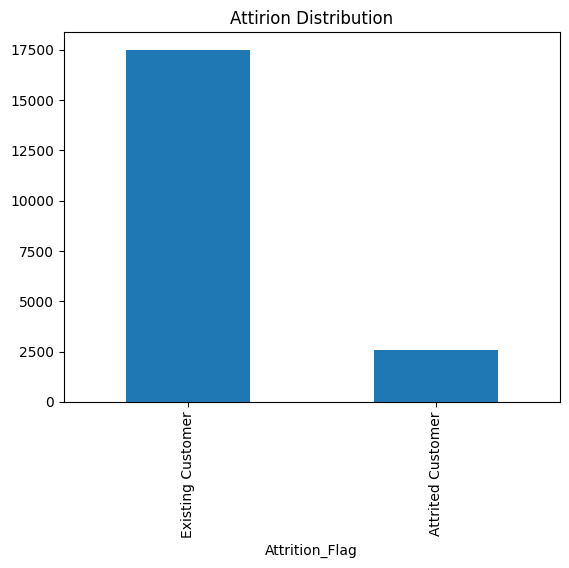

In [3]:
df['Attrition_Flag'].value_counts().plot(kind='bar')
plt.title("Attirion Distribution")
plt.show()

The dataset shows a strong class imbalance, where most customers remain active while a smaller proportion have attrited. This imbalance is important to consider when building predictive models.

# 2. Total_trans_Ct vs Attrition_Flag


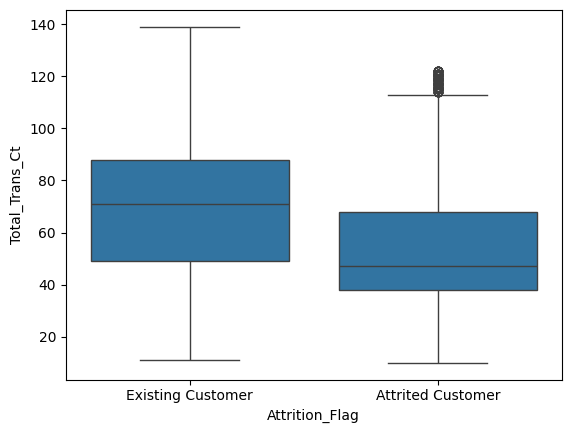

In [4]:
import seaborn as sns
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Ct', data=df)
plt.show()

The distribution of transaction counts is noticeably higher for existing customers, while attrited customers tend to have lower transaction counts.
There is a clear difference in transaction behavior between groups, where attrited customers tend to have significantly lower transaction counts than existing customers.
This suggests that reduced customer engagement is a strong indicator of potential churn.


# 3. Inactive vs Attrition

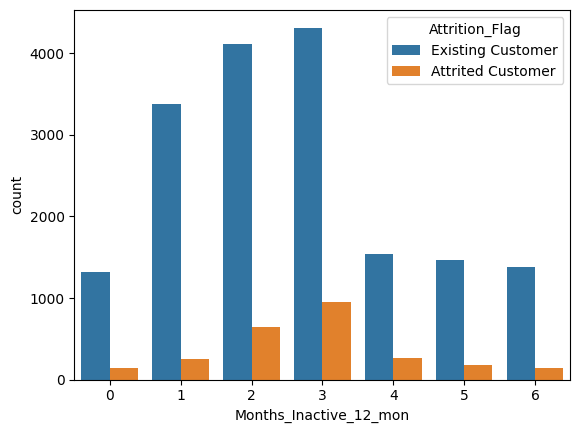

In [5]:
sns.countplot(x='Months_Inactive_12_mon', hue='Attrition_Flag', data=df)
plt.show()

As the number of inactive months increases, the proportion of attrited customers also increases, indicating a clear relationship between inactivity and customer churn.
Customers who remain inactive for longer periods are more likely to attrite, suggesting that reduced engagement is a key driver of churn.
This suggests that monitoring customer inactivity can help businesses identify at-risk customers early and take proactive retention actions.

# 4. Credit usage


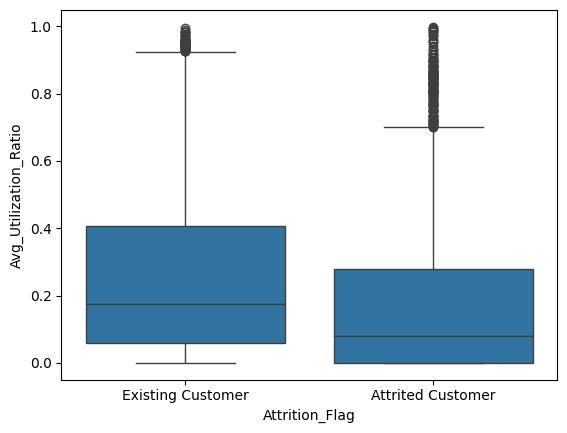

In [6]:
sns.boxplot(x='Attrition_Flag', y='Avg_Utilization_Ratio', data=df)
plt.show()

# Age vs Churn

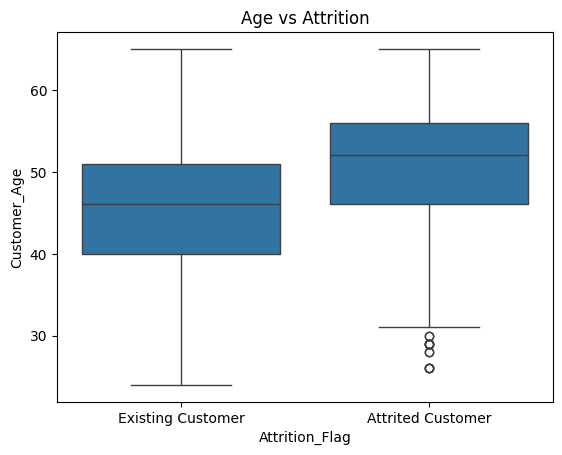

In [7]:
sns.boxplot(x="Attrition_Flag", y="Customer_Age", data=df)
plt.title("Age vs Attrition")
plt.show()

# Transactions vs Churn

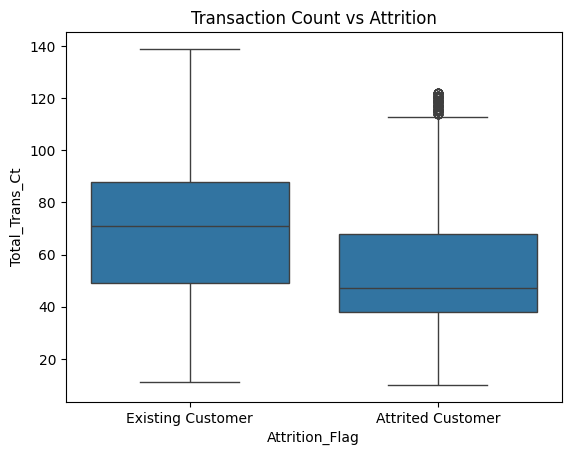

In [8]:
sns.boxplot(x="Attrition_Flag", y="Total_Trans_Ct", data=df)
plt.title("Transaction Count vs Attrition")
plt.show()

In [9]:
#Utilization vs Churn

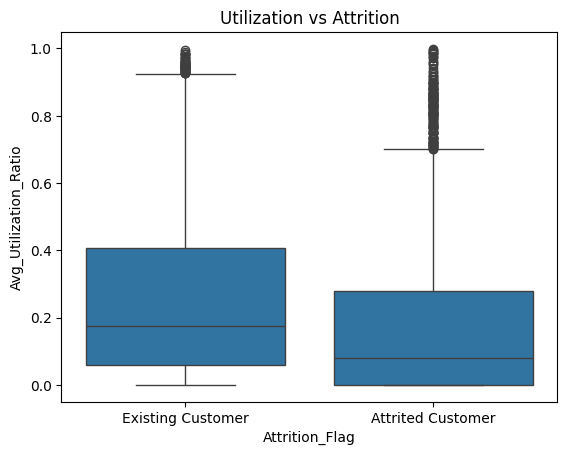

In [10]:
sns.boxplot(x="Attrition_Flag", y="Avg_Utilization_Ratio", data=df)
plt.title("Utilization vs Attrition")
plt.show()

The median utilization ratio is lower for attrited customers, suggesting that they use their credit less actively compared to existing customers.
Customers who use their credit cards less frequently tend to have a higher risk of attrition, indicating reduced engagement.
This suggests that customers with low credit utilization may require targeted engagement strategies to prevent churn.

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load data
df = pd.read_excel("../data/raw/credit_card_og.xlsx")

os.makedirs("../dashboard/static", exist_ok=True)

# ----------------------------
# 1. Churn Distribution
# ----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="Attrition_Flag", data=df)
plt.title("Customer Attrition Distribution")

plt.savefig("../dashboard/static/churn_distribution.png")
plt.close()

# ----------------------------
# 2. Age Distribution
# ----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df["Customer_Age"], bins=30, kde=True)
plt.title("Customer Age Distribution")

plt.savefig("../dashboard/static/age_distribution.png")
plt.close()

# ----------------------------
# 3. Transactions vs Churn
# ----------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x="Attrition_Flag", y="Total_Trans_Ct", data=df)
plt.title("Transaction Count vs Attrition")

plt.savefig("../dashboard/static/transactions_vs_churn.png")
plt.close()

# ----------------------------
# 4. Utilization vs Churn
# ----------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x="Attrition_Flag", y="Avg_Utilization_Ratio", data=df)
plt.title("Utilization vs Attrition")

plt.savefig("../dashboard/static/utilization_vs_churn.png")
plt.close()

print("EDA plots saved!")

EDA plots saved!


# Statistical Validation

In [14]:
from scipy.stats import ttest_ind, chi2_contingency

# Split groups
attrited = df[df["Attrition_Flag"] == "Attrited Customer"]
existing = df[df["Attrition_Flag"] == "Existing Customer"]

# ----------------------------
# H1: Transaction Count
# ----------------------------
t_stat, p_val = ttest_ind(attrited["Total_Trans_Ct"], existing["Total_Trans_Ct"])

print("H1 - Transaction Count")
print("T-stat:", t_stat)
print("P-value:", p_val)

# ----------------------------
# H2: Credit Utilization
# ----------------------------
t_stat, p_val = ttest_ind(attrited["Avg_Utilization_Ratio"], existing["Avg_Utilization_Ratio"])

print("\nH2 - Utilization Ratio")
print("T-stat:", t_stat)
print("P-value:", p_val)

# ----------------------------
# H3: Inactivity vs Attrition
# ----------------------------
contingency = pd.crosstab(df["Attrition_Flag"], df["Months_Inactive_12_mon"])

chi2, p, _, _ = chi2_contingency(contingency)

print("\nH3 - Inactivity vs Attrition")
print("Chi-square:", chi2)
print("P-value:", p)

# ----------------------------
# BONUS: Income vs Attrition
# ----------------------------
contingency_income = pd.crosstab(df["Attrition_Flag"], df["Income_Category"])

chi2_inc, p_inc, _, _ = chi2_contingency(contingency_income)

print("\nIncome vs Attrition")
print("Chi-square:", chi2_inc)
print("P-value:", p_inc)

H1 - Transaction Count
T-stat: -27.636488548413986
P-value: 4.947083166131547e-165

H2 - Utilization Ratio
T-stat: -14.279210451622859
P-value: 4.95793989358953e-46

H3 - Inactivity vs Attrition
Chi-square: 288.9797734018612
P-value: 1.8771356051486651e-59

Income vs Attrition
Chi-square: 32.863037264702
P-value: 1.2741405958248633e-06
